# Baseline — GitHub Model2

[원본 Model2.ipynb](https://github.com/choco9966/IEEE-CIS-Fraud-Detection/blob/main/Model2.ipynb)의
피처와 학습 구조를 원본 CSV부터 실행한다. 원본 파일은 대회 루트의 `Model2.ipynb`에 보존했다.
출처 commit과 파일 해시는 `source.json`에 있다.

**흐름**: CSV 결합 → 이메일/기기/시간 → 빈도/UID 집계 → LDA → 범주 조합/거래 순서
→ 인코딩 → ProductCD 두 그룹의 5-fold LightGBM → OOF/submission 저장.

원본의 중복 seed 실행과 진단용 그림은 줄였다. 사전 집계는 원본처럼 train+test를 사용한다.
타깃 평균 인코딩만 각 fold의 학습 라벨로 계산한다. 이 수정 때문에 원본의 CV 숫자와는 다를 수 있다.
무작위 CV와 전체 배치의 next-click 피처를 유지하므로 미래 거래 예측 성능은 별도 시간순 검증이 필요하다.

## 이 노트북을 읽는 방법

코드를 실행하기 전에 바로 위의 설명을 읽어보세요. **어떤 질문을 푸는지 → 작은 예시로 계산 → 실제 코드의 변수와 연결 → 출력 해석** 순서로 설명합니다.
코드 아래의 관찰은 이미 저장된 실행 결과를 읽는 안내입니다. '해볼 실험'은 아직 실행하지 않은 제안이며, 실제 결과와 구분했습니다.

처음 읽을 때 함수 이름을 모두 외울 필요는 없습니다. 새 피처를 만날 때마다 **'이 숫자는 무엇을 요약하며, 예측할 때도 알 수 있는가?'**를 물어보세요.
EDA에서 찾은 차이가 모델 성능 개선을 뜻하지는 않습니다. 실험 노트북에서는 **검증 데이터를 정한 뒤 구성 요소 하나씩 비교**해야 개선의 근거를 얻습니다.

처음에는 `01_eda_report` → GitHub `baseline`을 읽고, 이후 `02_winner_eda` → `winner_xgb` → `winner_lgbm` → `winner_catboost` → `winner_blend`로 이어가세요.
우승자 공개 baseline과 최종 우승 제출 전체는 구분합니다.

설명을 보강하면서 학습 코드·기존 표·그래프·실행 범위를 유지했습니다. 이 노트북의 **저장된 출력**과 설정의 **다음 실행 기본값**이 다를 수 있으므로 첫 실행 범위와 metrics를 먼저 확인하세요.


### 처음 만나는 용어는 여기서 잠깐 확인하세요

| 용어 | 여기서 뜻하는 것 |
|---|---|
| 피처(feature) | 모델에 입력할 거래의 정보. 원본 열과 새로 계산한 열 모두 포함 |
| NaN / 결측 | 값이 관측되지 않음. 실제 숫자 0과 다른 상태 |
| fold / validation | 교차검증의 한 분할 / 그 분할에서 평가용으로 제외한 데이터 |
| OOF | 각 train 행을 그 행 없이 학습한 모델로 예측해서 모은 값 |
| smoke | 전체 학습 전에 축소 데이터·rounds로 실행 흐름을 확인하는 실험 |
| leaf | tree에서 조건을 따라 내려간 끝의 구역. 그 구역에 들어온 행에 같은 보정을 줌 |

**제거 실험(ablation)**은 피처나 기법 하나를 뺀 모델을 같은 검증에서 비교하는 방법입니다. '있을 때 좋았으니 도움이 된다'에서 한 걸음 더 나아가 실제 기여를 확인하려는 실험입니다.

**작성 시 실행 확인 범위** — 2026-09-18, 원본 train/test 앞 30,000행씩,
2-fold, 최대 100 rounds의 smoke 실행이다. 전체 데이터 학습의 점수가 아니다.
기본 설정으로 다시 실행하면 전체 데이터, 5-fold, 최대 15,000 rounds를 사용한다.
실제 실행 범위는 아래 설정 출력과 해당 metrics.json을 따른다.

## 0. 설정과 데이터

### 먼저 입력, 정답, 거래 번호를 서로 떼어둡니다

`y`는 맞혀야 할 0/1 정답, `train_ids/test_ids`는 결과를 원래 거래에 되돌려 붙일 키, `all_data`는 특징 추출에 쓸 입력입니다.
`train.drop(columns='isFraud')`를 한 다음 test와 합치므로 아래 그룹 평균/LDA가 사기 정답을 직접 보지는 않습니다. **train+test 입력으로 변환을 만드는 것**과 **test 정답을 사용하는 것**을 구분하세요.

합친 이유는 빈도와 기기/주소 동시 출현을 test 입력까지 포함해 계산하는 원문의 배치 방식 때문입니다. 같은 방식을 실시간 미래 예측에 옮길 때는 사용할 수 있는 정보 범위를 다시 정해야 합니다.
train을 먼저 concat했으므로 나중에 `iloc[:n_train]`로 분리합니다. 중간에 전체 행을 정렬하면 이 기준이 깨질 수 있어 행 순서 유지가 중요합니다.

출력 로그의 NROWS/folds/rounds가 **현재 저장된 실행 범위**입니다. 아래 코드의 기본값은 전체 5-fold/15,000 rounds지만 저장된 출력은 앞 30,000행씩/2-fold/100 rounds입니다.
TAG는 결과를 구분하는 폴더 이름입니다. 같은 태그로 다시 실행하면 덮어쓰므로 비교 실험에서는 어떤 설정의 결과인지 함께 남깁니다.

In [1]:
import gc
import json
import os
import sys
import time
import warnings
from importlib.metadata import version
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from joblib import parallel_backend
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

cwd = Path.cwd()
PROJECT_DIR = next(p for p in (cwd, *cwd.parents) if (p / "source.json").is_file())
sys.path.insert(0, str(PROJECT_DIR))
from data.loader import load_data, load_sample_submission

NROWS = int(os.environ["IEEE_NROWS"]) if os.getenv("IEEE_NROWS") else None
N_SPLITS = int(os.getenv("IEEE_FOLDS", "5"))
NUM_BOOST_ROUND = int(os.getenv("IEEE_ROUNDS", "15000"))
NUM_THREADS = int(os.getenv("IEEE_THREADS", "8"))
SEED = 42
TAG = os.getenv("IEEE_TAG", "baseline" if NROWS is None else "smoke")
assert N_SPLITS >= 2 and NUM_BOOST_ROUND > 0 and NUM_THREADS > 0
assert TAG == Path(TAG).name and TAG not in {".", ".."}
assert NROWS is None or (NROWS > 0 and TAG != "baseline")
OUTPUT_DIR = PROJECT_DIR / "experiments/baseline/outputs" / TAG
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "run.log").write_text("", encoding="utf-8")

def log(message):
    print(message, flush=True)
    with (OUTPUT_DIR / "run.log").open("a", encoding="utf-8") as stream:
        stream.write(str(message) + "\n")

warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
started = time.time()
source = json.loads((PROJECT_DIR / "source.json").read_text(encoding="utf-8-sig"))
train, test = load_data(nrows=NROWS)
n_train = len(train)
y = train.isFraud.astype("int8").reset_index(drop=True)
train_ids, test_ids = train.TransactionID.to_numpy(), test.TransactionID.to_numpy()
all_data = pd.concat([train.drop(columns="isFraud"), test], ignore_index=True)
del train, test
gc.collect()
log(f"train={n_train}, test={len(test_ids)}, NROWS={NROWS}, folds={N_SPLITS}, rounds={NUM_BOOST_ROUND}")
log(f"source commit={source['commit']}")

train=30000, test=30000, NROWS=30000, folds=2, rounds=100


source commit=fef0b14cc3fb392a4b27c6ba77058b6a6e7f1ed1


## 1. 이메일, M 피처와 기기

### 사람이 읽는 정보를 모델이 비교하기 쉬운 관점으로 바꿉니다

이메일 P/R이 같으면 '두 역할에서 같은 도메인을 사용한다'는 신호입니다. 그런데 **둘 다 비어 있음**과 **값이 실제로 같음**은 다른 상태여서 별도 결측 표시를 만듭니다.
`.co.jp`의 마지막 `jp` 같은 접미사는 서비스권역 단서일 수 있지만 사용자의 실제 국가를 확정하지 않습니다. gmail/com/net 등은 같은 의미로 취급할 수 없어 일부를 비웁니다.

M은 익명 일치 관련 피처입니다. T/F를 1/0으로 바꾸고, 관측된 4개 중 T가 3개면 `M_not_null=4`, `M_sum=3`, `collect_agree_ratio=.75`입니다.
T 개수만 쓰면 **측정된 항목 수의 차이**와 **일치 성향**이 섞입니다. 비율을 함께 넣는 이유입니다. 전부 결측이면 분모가 0이라 비율은 NaN이며, '전부 불일치'인 0과 구분됩니다.

DeviceInfo에 수많은 모델명/버전이 있으면 각 문자열을 따로 배우기 어렵습니다. 소문자화와 규칙 치환으로 samsung/windows 같은 큰 계열을 만들고 원본과 파생 정보를 같이 둡니다.
예를 들어 `Chrome 70.0`은 chrome 계열과 숫자 부분 `700`으로 나뉩니다. **700이 실제 버전 700이라는 뜻은 아닙니다.** 점을 제거한 문자 코드입니다.
규칙의 적용 순서나 문자열에 포함된 부분 때문에 오분류가 생길 수 있습니다. 이런 규칙은 데이터에 맞춘 후보 피처이며 정확한 기기 판정 시스템이 아닙니다.

In [2]:
p_email, r_email = all_data.P_emaildomain, all_data.R_emaildomain
all_data["email_check"] = (p_email == r_email).astype("int8")
all_data["email_check_nan_all"] = (p_email.isna() & r_email.isna()).astype("int8")
all_data["email_check_nan_any"] = (p_email.isna() | r_email.isna()).astype("int8")
for col in ["P_emaildomain", "R_emaildomain"]:
    all_data[col] = all_data[col].fillna("email_not_provided")
    country = all_data[col].str.split(".").str[-1]
    all_data[col + "_Country"] = country.mask(country.isin(["email_not_provided", "com", "net", "gmail", "edu"]))
    all_data[col + "_prefix"] = all_data[col].str.split(".").str[0]

m_cols = [f"M{i}" for i in range(1, 10) if i != 4]
all_data["M_not_null"] = all_data[m_cols].notna().sum(axis=1)
for col in m_cols:
    all_data[col] = all_data[col].map({"T": 1, "F": 0})
all_data["M_sum"] = all_data[m_cols].sum(axis=1)
all_data["collect_agree_ratio"] = all_data.M_sum / all_data.M_not_null

device_rules = {"sm": "samsung", "samsung": "samsung", "huawei": "huawei", "moto": "moto",
                "rv": "rv:", "trident": "trident", "lg": "lg", "htc": "htc", "blade": "blade",
                "windows": "windows", "lenovo": "lenovo", "linux": "linux", "f3": "f3", "f5": "f5",
                "ios": "apple", "mac": "apple"}
all_data["DeviceInfo"] = all_data.DeviceInfo.fillna("unknown_device").str.lower()
all_data["DeviceInfo_c"] = all_data.DeviceInfo
for key, value in device_rules.items():
    all_data["DeviceInfo_c"] = all_data.DeviceInfo_c.mask(all_data.DeviceInfo_c.str.contains(key, regex=False), value)
all_data["DeviceInfo_c"] = all_data.DeviceInfo_c.where(all_data.DeviceInfo_c.isin(device_rules.values()), "other_d_type")

all_data["id_30"] = all_data.id_30.fillna("unknown").str.lower()
all_data["id_30_c"] = all_data.id_30
for key, value in {"win": "windows", "mac": "mac", "ios": "ios", "and": "android", "linux": "linux"}.items():
    all_data["id_30_c"] = all_data.id_30_c.mask(all_data.id_30_c.str.contains(key, regex=False), value)
all_data.loc[all_data.id_30 == "unknown", "id_30_c"] = np.nan
all_data["id_30_v"] = all_data.id_30.str.replace(r"\D", "", regex=True)

browsers = ["safari", "ie", "chrome", "edge", "firefox", "samsung", "opera", "google", "android"]
all_data["id_31"] = all_data.id_31.fillna("unknown").str.lower()
all_data["id_31_c"] = all_data.id_31
for browser in browsers:
    all_data["id_31_c"] = all_data.id_31_c.mask(all_data.id_31_c.str.contains(browser, regex=False), browser)
all_data.loc[all_data.id_31 == "unknown", "id_31_c"] = np.nan
all_data.loc[all_data.id_31_c.notna() & ~all_data.id_31_c.isin(browsers + ["other"]), "id_31_c"] = "other"
all_data["is_mobile_browser"] = all_data.id_31.str.contains("mobile", regex=False).astype("int8")
all_data["id_31_v"] = all_data.id_31.str.replace(r"\D", "", regex=True)

## 2. 시간, 빈도와 UID 집계

### 한 거래에 '이 그룹의 평소 모습'을 붙입니다

`value_counts→map`은 범주의 등장 횟수를 각 행에 돌려줍니다. 카드 A가 100번, B가 2번 등장하면 각각 100/2를 받습니다. 이 구현의 빈도는 비율이 아니라 **건수**이며 기본 value_counts는 결측을 세지 않습니다.
자주 등장하는 카드가 안전하다는 뜻은 아닙니다. 정상 고객의 활동 또는 반복 사기일 수 있습니다. 모델이 다른 피처와 함께 관계를 배워야 합니다.

UID는 card/addr 코드를 이어서 여러 수준의 그룹을 만듭니다. 같은 card1의 금액 [10,10,40]이면 `mean=20`, `std≈17.32`를 세 거래에 모두 붙입니다.
표본 std의 계산은 `sqrt(((10-20)²+(10-20)²+(40-20)²)/(3-1))≈17.32`입니다. 평균에서 벗어난 거리의 제곱을 모아 변동을 나타내고, 표본에서는 분모가 n-1입니다.
같은 금액만 반복되면 std는 0이고, 관측이 1건이면 이 분모가 0이라 NaN입니다. '항상 같은 금액'과 '변동을 판단할 자료가 부족함'을 구분할 수 있습니다.

`groupby.transform`은 그룹마다 하나의 숫자를 구해 **원래 행 수/순서로 펼쳐 돌려주는 연산**입니다. 집계 뒤 merge하는 것과 같은 목적이며 여러 키를 넣으면 그 조합별 그룹입니다.

`TransactionDT-D_i일`은 D의 의미가 시간차라는 가정 아래 시작일을 추정하는 후보입니다. 100일째 D1=20, 105일째 D1=25가 같은 시작일 80을 가리키는 식입니다.
`dow/day/Transaction_hour`는 각각 요일·월의 일자·시간입니다. 기준 날짜가 가정이므로 요일/휴일 해석도 그 가정에 달려 있습니다.
`ymd` 기준 거래 count와 금액 sum은 그날의 전체 활동 규모를 붙입니다. 이는 라벨 평균이 아니지만 하루 전체를 사용하는 배치 집계입니다.
`uid2_dayofweek_*`라는 출력 이름과 달리 실제 그룹 키는 uid3+ProductCD입니다. 요일의 단순 평균은 6(일요일)과 0(월요일)의 순환 거리까지 표현하지는 못합니다.
함수 안에서는 일수의 소수를 버리고 날짜 단위로 묶습니다. `account_make_date`라는 변수명만으로 실제 계정 개설일이 알려진 것은 아닙니다.
금액의 소수 부분도 결제 체계/가격 패턴을 나타낼 후보입니다. 부동소수 표현 때문에 decimal_count가 의도와 다르게 길어질 수 있어 이 피처를 의미 그대로 믿기보다는 ablation으로 봅니다.

In [3]:
seconds = all_data.TransactionDT.copy()
all_data["TransactionDT"] = pd.Timestamp("2017-11-30") + pd.to_timedelta(seconds, unit="s")
dt = all_data.TransactionDT.dt
all_data["dow"], all_data["day"], all_data["Transaction_hour"] = dt.dayofweek, dt.day, dt.hour
all_data["ymd"] = dt.year * 10000 + dt.month * 100 + dt.day

frequency_cols = (
    ["card1", "card2", "card3", "card5"] + [f"C{i}" for i in range(1, 15)]
    + [f"D{i}" for i in range(1, 10)] + ["addr1", "addr2", "dist1", "dist2", "P_emaildomain", "R_emaildomain"]
    + [f"id_{i:02d}" for i in list(range(1, 12)) + [13, 14, 17, 18, 19, 20, 21, 22, 24, 25, 26, 30, 31, 32, 33]]
    + ["DeviceInfo", "DeviceInfo_c", "id_30_c", "id_30_v", "id_31_v"]
)
for col in frequency_cols:
    all_data[col + "_fq_enc"] = all_data[col].map(all_data[col].value_counts())

def add_group(keys, column, stats, prefix):
    grouped = all_data.groupby(keys, sort=False)[column]
    for stat in stats:
        all_data[f"{prefix}_{stat}"] = grouped.transform(stat)

all_data["uid"] = all_data.card1.astype(str) + "_" + all_data.card2.astype(str)
all_data["uid2"] = all_data.uid + "_" + all_data.card3.astype(str) + "_" + all_data.card4.astype(str)
all_data["uid3"] = all_data.uid2 + "_" + all_data.addr1.astype(str) + "_" + all_data.addr2.astype(str)
for col in ["card1", "card2", "card3", "card5", "uid", "uid2", "uid3"]:
    add_group(col, "TransactionAmt", ["mean", "std"], col + "_TransactionAmt")
add_group("ymd", "TransactionDT", ["count"], "ymd_TransactionDT")
add_group("ymd", "TransactionAmt", ["sum"], "ymd_TransactionAmt")
add_group(["uid3", "ProductCD"], "dow", ["mean", "std"], "uid2_dayofweek")

decimal = all_data.TransactionAmt - all_data.TransactionAmt.astype(int)
all_data["TransactionAmt_decimal_count"] = decimal.astype(str).str.split(".").str[1].str.len()
all_data["TransactionAmt_decimal"] = (decimal * 1000).astype(int)
for col in ["D1", "D2", "D4", "D8", "D10", "D15"]:
    account_date = (all_data.TransactionDT - pd.to_timedelta(np.trunc(all_data[col]), unit="D")).dt.floor("D")
    all_data["account_make_date_" + col] = account_date.dt.year * 10000 + account_date.dt.month * 100 + account_date.dt.day
add_group(["card1", "account_make_date_D1", "ProductCD"], "TransactionAmt", ["mean", "std"],
          "card1_make_date_D1_productCD_Amt")

## 3. LDA와 범주 조합

### 카드의 주소 사용 패턴을 5개 숫자로 압축하는 LDA

여기의 LDA는 **Latent Dirichlet Allocation**, 즉 토픽 모델입니다. 판별분석 Linear Discriminant Analysis와 다른 방법입니다.
문서는 card1 그룹, 단어는 함께 관측된 addr1 또는 id_20 값입니다. 카드 A의 주소가 [100,100,200]이면 '100 100 200'이라는 문서를 만들어 단어 빈도로 표현합니다.

| 그룹 | token 100 | token 200 | token 300 |
|---|---:|---:|---:|
| 카드 A | 2 | 1 | 0 |
| 카드 B | 0 | 1 | 3 |

LDA는 문서가 여러 토픽의 혼합이고 토픽마다 자주 나오는 단어가 다르다고 가정해 반복 추정합니다.
개념적으로 `P(token|card)=Σ P(topic|card)×P(token|topic)`입니다. 결과가 [.7,.2,.1,0,0]처럼 나오면 해당 카드의 토픽 혼합 정도를 5개 열로 붙입니다. 각 문서의 가중치 합은 약 1입니다.
이 과정을 주소 사용 패턴으로 생각해볼까요? 어떤 잠재 패턴은 주소 100/200을 자주 쓰고, 다른 패턴은 300을 자주 쓴다고 가정합니다.
카드 A의 관측 주소를 잘 설명하도록 A의 패턴 혼합 비율을 고치고, 여러 카드의 관측을 잘 설명하도록 각 패턴의 주소 비율도 고칩니다.
이 두 추정을 반복해 **수많은 주소 조합을 적은 수의 혼합 비율로 요약**합니다. Dirichlet prior는 그 혼합 비율에 대한 가정으로, 데이터가 적을 때의 추정에도 영향을 줍니다.
주소 100 같은 token은 이 모델에서 단어 이름표여서 200이 100의 두 배라는 산술을 하지 않습니다.
세 번째 `add_topics(card4, DeviceInfo_c, NMF)`는 카드 브랜드 그룹의 기기 계열 동시 출현에 같은 방법을 적용합니다. 세 조합×5토픽으로 15개 열을 만듭니다.

**토픽 0이 사기, 토픽 1이 정상이라는 뜻은 없습니다.** 이 단계는 정답을 안 보고 함께 등장하는 패턴을 압축합니다. LightGBM이 그 표현과 사기의 관계를 나중에 배웁니다.

`dropna()`로 token이 없는 조합은 문서에서 빠집니다. 같은 그룹의 결과를 다시 map하고, 결과가 없는 그룹은 결측으로 남습니다. CountVectorizer의 기본 tokenizer는 구두점/짧은 token도 처리하므로 원래 숫자 문자열을 그대로 보존하는 인코더는 아닙니다.
원본 `_NMF_` 열도 실제로 LDA를 실행합니다. `n_components=5`는 원문 설정이지 이 데이터에서 최적임을 검증한 결과가 아닙니다.
아래 범주 조합은 두 값의 **함께 발생하는 경우**를 별도 범주로 만들고 그 빈도/금액을 요약합니다. [LDA 문서](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.LatentDirichletAllocation.html)를 참고하세요.

In [4]:
def add_topics(key, token, name):
    documents = (all_data[[key, token]].dropna().groupby(key, sort=False)[token]
                 .agg(lambda values: " ".join(values.astype(str))))
    counts = CountVectorizer().fit_transform(documents)
    with parallel_backend("threading"):
        topics = LatentDirichletAllocation(n_components=5, n_jobs=NUM_THREADS, random_state=0).fit_transform(counts)
    for i in range(5):
        all_data[f"{key}_{token}_{name}_{i}"] = all_data[key].map(pd.Series(topics[:, i], index=documents.index))
    log(f"{name}: {key}/{token}, groups={len(documents)}, vocabulary={counts.shape[1]}")

add_topics("card1", "addr1", "LDA")
add_topics("card1", "id_20", "LDA")
add_topics("card4", "DeviceInfo_c", "NMF")

for first, second in [("addr1", "id_32"), ("addr1", "id_14"), ("addr1", "id_19"),
                      ("card1", "card2"), ("card1", "addr1")]:
    col = f"{first}_{second}_combine"
    all_data[col] = pd.factorize(all_data[first].astype(str) + "_" + all_data[second].astype(str), sort=True)[0]
    all_data[col + "_fq_enc_combine"] = all_data[col].map(all_data[col].value_counts())
    if col != "card1_card2_combine":
        add_group(col, "TransactionAmt", ["mean", "std"], col + "_TransactionAmt")

LDA: card1/addr1, groups=5457, vocabulary=182


LDA: card1/id_20, groups=2379, vocabulary=174


NMF: card4/DeviceInfo_c, groups=4, vocabulary=15


### 확인 질문
LDA의 5개 열은 사기 유형을 감독학습한 결과일까요? 아닙니다. 카드가 어떤 token 조합을 사용하는지 압축한 표현입니다.
**해볼 실험:** 같은 fold에서 이 15개 토픽 열만 빼보세요. 토픽 수 3/5/10 비교는 그 다음 질문이며 검증을 계속 바꿔가며 고르면 비교가 흐려집니다.

## 4. 거래 순서와 추가 집계

### 거래 순서 피처는 '언제 알 수 있는 정보인가'를 먼저 봅니다

`groupby(uid3).shift(-1)`은 같은 UID의 다음 행 시각을 현재 행에 가져옵니다. 현재가 10초, 다음이 18초면 이 코드의 next-click은 **10-18=-8초**입니다.
절댓값이 작으면 가까운 간격의 활동을 나타낼 수 있고 마지막 거래는 다음 값이 없어 NaN입니다. 거래 시간으로 정렬하지 않고 원본 행 순서를 사용하므로 '다음 행'이 실제 다음 거래라는 전제도 확인해야 합니다.
**다음 거래는 현재 거래 순간에는 모릅니다.** 정답을 쓰지 않더라도 미래 이벤트를 보는 배치 피처입니다. 온라인용으로는 과거 거래와의 간격을 별도 설계해야 합니다.

ProductCD의 금액이 순서대로 [10,30,20]이면 `cumsum/(cumcount+1)`은 [10,20,20]입니다. 이는 현재 거래까지 포함한 누적 평균이고, 학습/검증 정답을 사용하지 않습니다. 현재/검증의 입력을 보는 것은 정보 시점 문제와 구분합니다.
금액 min-max는 상품별 최소/최대로 `(금액-min)/(max-min)`을 구합니다. 상품 내 상대 위치를 표현하지만 최소/최대는 전체 train+test에서 구합니다.

코드 순서를 따라 단위를 구분하세요. 이 셀 앞부분의 금액 집계는 **원 금액**으로 만들고, 변환 뒤 `id_02_ProductCD_amt` 집계는 **상품별 min-max 금액**으로 만듭니다.
이름에 Amt가 같아도 의미/단위가 같지 않습니다. 나중의 중요도 해석에서도 어느 단계에서 만든 열인지 돌아와 확인해야 합니다.

In [5]:
all_data["uid3_next_click"] = seconds - seconds.groupby(all_data.uid3, sort=False).shift(-1)
amount_groups = [
    (["card1", "account_make_date_D2", "ProductCD"], "card1_make_date_D2_productCD_Amt"),
    (["card1", "addr1", "account_make_date_D1", "ProductCD"], "card1_addr1_make_date_D1_ProductCD_Amt"),
    (["card1", "id_20", "account_make_date_D1", "ProductCD"], "card1_id_20_make_date_D1_ProductCD_Amt"),
]
for keys, prefix in amount_groups:
    add_group(keys, "TransactionAmt", ["mean", "std"], prefix)

product_amount = all_data.groupby("ProductCD", sort=False).TransactionAmt
all_data["ProductCD_Amt_expandmean"] = product_amount.cumsum() / (product_amount.cumcount() + 1)
amount_min, amount_max = product_amount.transform("min"), product_amount.transform("max")
all_data["TransactionAmt"] = (all_data.TransactionAmt - amount_min) / (amount_max - amount_min).replace(0, 1)
del product_amount, amount_min, amount_max, decimal

for keys, prefix in [
    (["card1", "account_make_date_D1", "ProductCD"], "card1_make_date_D1_ProductCD_dist1"),
    (["card1", "addr1", "account_make_date_D1", "ProductCD"], "card1_addr1_make_date_D1_ProductCD_dist1"),
    (["card1", "card2", "account_make_date_D1", "ProductCD"], "card1_card2_make_date_D1_ProductCD_dist1"),
]:
    add_group(keys, "dist1", ["mean", "std"], prefix)
add_group(["id_02", "ProductCD"], "TransactionAmt", ["mean"], "id_02_ProductCD_amt")
add_group(["card1", "account_make_date_D1", "ProductCD"], "Transaction_hour", ["mean"],
          "card1_make_date_D1_productCD_hour")

all_data["card1_maked1_pcd"] = pd.factorize(all_data.card1.astype(str)
    + all_data.account_make_date_D1.astype(str) + all_data.ProductCD.astype(str))[0]
for col in ["card1_maked1_pcd", "account_make_date_D1"]:
    all_data[col + "_fq_enc_combine"] = all_data[col].map(all_data[col].value_counts())
all_data["d1_d2"] = (all_data.account_make_date_D1.astype(str) + "_"
                     + all_data.account_make_date_D2.astype(str) + "_" + all_data.ProductCD.astype(str))
all_data["same_d1_d2"] = (all_data.account_make_date_D1 == all_data.account_make_date_D2).astype("int8")
all_data["d1_d2_fq_enc"] = all_data.d1_d2.map(all_data.d1_d2.value_counts())
del seconds, dt, account_date, p_email, r_email, country
gc.collect()

109

## 5. 인코딩과 모델 설정

### 인코딩과 실제 모델 입력 목록 읽기

`factorize`는 문자열마다 숫자 이름표를 부여합니다. A=0/B=1/C=2가 B가 A보다 크다는 의미를 주지는 않습니다.
`categorical`로 지정한 열은 LightGBM이 범주로 취급하지만, 그 목록 밖의 숫자 코드는 수치 분기 대상입니다. **인코딩을 했다는 것과 올바르게 범주형으로 선언했다는 것은 다른 단계**입니다.
-1은 factorize의 결측 표시입니다. 학습 셀은 범주형 열의 음수를 NaN으로 맞춰 누락으로 처리합니다. 실수 열의 float32는 메모리 조정입니다.

`common_drop`은 입력에서 제외할 열, `common_cat/extra_cat`은 범주로 읽을 열, `product_groups`는 어떤 거래를 어느 모델에 맡길지 정합니다.
실제 피처는 그룹마다 상수 열도 제외하므로 만든 모든 열을 학습에 쓰지는 않습니다. 최빈 상품의 단일 ProductCD target mean은 상수가 되어 제외합니다.
원본 출력 이름의 goss와 달리 실제 `boosting_type='gbdt'`입니다. 파라미터 이름을 보고 실행하는 알고리즘을 확인하는 습관을 들이세요.

### '이 범주는 사기가 얼마나 많았는가'를 입력으로 쓰는 방법

Target mean encoding은 학습 데이터에서 범주별 정답 평균을 구해 피처로 넣습니다. 학습 fold에서 M4=A의 라벨이 [0,0,1,0]이면 값은 .25입니다.
검증 A도 .25를 받고, 학습에 없던 B는 그 fold 전체 사기율을 받습니다. **검증 B의 정답이 1이어도 인코딩을 만들 때 알면 안 됩니다.**

그래서 코드는 **fold 분리 → fit 정답으로 mapping 작성 → fit/validation/test에 같은 mapping 적용** 순서입니다.
전체 train 정답으로 mapping을 만들고 CV하면 검증 정답 일부가 이미 피처에 들어가 점수가 낙관적으로 보일 수 있습니다.

주의할 구분이 하나 더 있습니다. 이 구현은 validation 정답은 제외하지만 fit 행의 인코딩에는 자기 정답도 평균의 일부로 들어갑니다.
범주가 1건뿐이면 평균이 정답 자체라 과적합하기 쉽습니다. **높은 cardinality에서는 내부 OOF 인코딩/leave-one-out/전체 평균으로 smoothing을 고려할 수 있습니다.** 여기서는 그 추가 기법을 구현하거나 효과를 검증한 것은 아닙니다.

### 먼저, 여러 tree를 왜 순서대로 더할까요?

한 tree는 '금액이 크고, 특정 기기이고, 어떤 카드 그룹인가'처럼 조건을 나눠 거래를 구분합니다. 여러 조건의 **상호작용**을 표현할 수 있습니다.
Gradient boosting은 새 tree를 독립적으로 평균내는 방식과 다릅니다. 앞의 예측이 놓친 방향을 다음 tree가 보정합니다.

이진 분류에서 예측 확률 p와 정답 y의 log loss는 `-[y log(p)+(1-y)log(1-p)]`입니다.
사기인데 p=.1이면 큰 벌점을 받고, 사기인데 p=.9이면 작은 벌점을 받습니다. logit 점수에 대한 음의 기울기는 `y-p`입니다.
사기 y=1,p=.1은 +.9 방향, 정상 y=0,p=.9는 -.9 방향으로 보정하도록 새 tree를 학습합니다. 실제 leaf 값은 여러 행의 기울기/가중치 등을 모아 구합니다.

개념적으로 `새 점수 = 이전 점수 + learning_rate × 새 tree 보정`이며 확률은 점수를 sigmoid로 바꿔 얻습니다.
작은 learning rate는 조금씩 고치는 대신 더 많은 tree가 필요합니다. **rounds를 크게 적었다고 반드시 그 수만큼 학습하는 것도, 최적 튜닝을 마친 것도 아닙니다.**

여기서 loss는 학습 방향을 정하고 AUC는 검증에서 순위를 평가합니다. **AUC를 지표로 적었어도 tree가 직접 AUC를 미분해 학습하는 것은 아닙니다.**
트리의 깊이/leaf 수는 복잡도, 행/열 표본 추출은 다양성과 과적합을, early stopping은 학습을 끝낼 시점을 조절합니다.
이 설명의 수식은 원리를 이해하기 위한 것이며 실제 새 tree는 단일 거래의 오차만으로 만들어지지 않습니다.

여기서 gradient(기울기)는 loss를 줄이려면 예측을 어느 방향으로 고칠지 알려줍니다.
확률 p를 `log(p/(1-p))`로 바꾼 점수를 **logit**이라 부릅니다. p=.5이면 0, p=.9이면 약 2.20입니다.
**Sigmoid**는 `1/(1+exp(-점수))`로 점수를 다시 0~1 확률로 바꿉니다. Tree 보정은 이 점수 공간에서 더하고 마지막에 확률로 읽습니다.


### 이 baseline에서 LightGBM을 쓰는 이유

금액·빈도·범주·그룹 통계가 함께 있고, 그 조합이 중요할 수 있어 조건을 나누는 tree가 자연스러운 출발점입니다. Tree는 결측 방향도 학습할 수 있습니다.
LightGBM은 수치 값을 histogram bin으로 묶어 분기를 빠르게 탐색하고, loss를 가장 크게 줄일 leaf부터 나누는 **leaf-wise** 방식으로 tree를 키웁니다.
한쪽 경로가 다른 쪽보다 더 깊어질 수 있습니다. 따라서 256 leaf를 depth=8로 읽으면 안 됩니다. 작거나 희귀한 그룹을 지나치게 잘게 나누는지는 검증으로 확인해야 합니다.
전처리만으로 좋은 모델이 되는 것도, 복잡한 모델이 모든 분포 변화에 대응하는 것도 아니어서 다음 셀의 검증이 필요합니다.

### LightGBM 설정의 역할

| 코드 설정 | 무엇을 바꾸나 | 이 값에서 생각할 점 |
|---|---|---|
| num_leaves=256, max_depth=-1 | tree의 leaf 수와 경로 길이 | 작은 그룹에서는 복잡할 수 있음 |
| learning_rate=.01 | 새 tree 보정의 크기 | 100 rounds만 보면 아직 덜 배웠을 수 있음 |
| feature_fraction=.7 | tree별 입력 열 일부 선택 | 같은 피처에만 의존하는 일을 줄일 후보 |
| bagging_fraction=.7, bagging_freq=1 | 반복별 학습 행 표본 | 희귀 사기 표본도 영향을 받음 |
| max_bin=255 | 연속값 분할 후보를 묶는 해상도 | 메모리/속도와 세밀함의 절충 |

이 값들은 원문 baseline 설정입니다. 우승 모델의 최적값이나 우리 검증에서 튜닝된 값으로 읽지 않습니다.
[LightGBM 알고리즘 설명](https://lightgbm.readthedocs.io/en/stable/Features.html)과 [튜닝 안내](https://lightgbm.readthedocs.io/en/stable/Parameters-Tuning.html)를 참고하세요.

In [6]:
product_names = all_data.ProductCD.copy()
for col in all_data.select_dtypes(include=["object", "string"]).columns:
    all_data[col] = pd.factorize(all_data[col], sort=True)[0]
for col in all_data.select_dtypes(include="floating").columns:
    all_data[col] = all_data[col].astype("float32")
all_data = all_data.copy()
x_train = all_data.iloc[:n_train].reset_index(drop=True)
x_test = all_data.iloc[n_train:].reset_index(drop=True)
del all_data
gc.collect()

params = dict(boost_from_average=True, boosting_type="gbdt", feature_fraction=0.7,
              bagging_fraction=0.7, learning_rate=0.01, bagging_freq=1, max_bin=255,
              max_depth=-1, metric="auc", num_leaves=256, num_threads=NUM_THREADS,
              tree_learner="serial", objective="binary", verbosity=-1, seed=SEED)
common_drop = ["DT_M", "card1_addr1_maked1_pcd", "card1_addr1_maked1_pcd_fq_enc_combine", "C13_over_cf_sum",
               "TransactionID", "isFraud", "TransactionDT", "bank_type", "uid", "uid2", "uid3", "ymd", "ym", "is_D_max", "addr1_null"]
common_cat = ["addr1", "addr2", "P_emaildomain"]
extra_cat = ["R_emaildomain", "id_13", "id_15", "id_33", "id_37", "id_38", "id_30_v", "id_31_v"]
product_counts = x_train.ProductCD.value_counts()
product_groups = [product_counts.index[:1].tolist(), product_counts.index[1:].tolist()]

def encode_target(fit, labels, valid, test, columns):
    for col in columns:
        mapping = labels.groupby(fit[col]).mean()
        for frame in (fit, valid, test):
            frame[col + "_target_mean"] = frame[col].map(mapping).fillna(labels.mean()).astype("float32")

log(f"Features prepared: train={x_train.shape}, test={x_test.shape}, elapsed={time.time() - started:.1f}s")

Features prepared: train=(30000, 603), test=(30000, 603), elapsed=10.4s


## 6. ProductCD별 5-fold 학습

### W/나머지 모델과 shuffled StratifiedKFold

먼저 상품군을 나누고 각 군 안에서 정답 비율을 비슷하게 맞춰 여러 fold로 나눕니다. 이것이 stratified의 의미입니다. 같은 고객을 통째로 나누거나 미래만 검증한다는 뜻은 아닙니다.
예를 들어 W 모델의 fold 1 검증 거래는 fold 1 학습에서 빠지고, 그 거래 위치에 예측을 기록합니다. test W 거래는 W의 모든 fold 모델 평균을 받습니다. 다른 상품 모델도 같은 방식입니다.
`oof[train_idx[valid_idx]]`의 두 단계 인덱싱은 **군 내부 위치를 전체 거래 위치로 돌려주는 것**입니다. 이를 틀리면 예측과 정답이 다른 거래에 붙습니다.

Early stopping 100은 validation AUC가 100 rounds 동안 개선되지 않으면 중단하는 설정입니다. `best_iteration`은 가장 좋았던 시점이며, 코드가 그 tree 수로 예측합니다.
저장된 smoke는 최대 100 rounds라 긴 early-stopping 동작을 충분히 시험한 실행은 아닙니다. 낮은 learning rate와 원문의 15,000 upper bound를 함께 고려해야 합니다.

상품군 AUC와 pooled OOF AUC는 다를 수 있습니다. 그룹 A의 위험 점수가 전체적으로 낮고 B가 높다면 그룹 사이 순위도 pooled AUC에 반영됩니다.
자기 그룹 안에서 모두 잘 정렬해도 그룹 간 스케일이 틀리면 전체 AUC가 낮아질 수 있어 둘을 함께 봅니다.

In [7]:
oof = np.full(n_train, np.nan)
predictions = np.full(len(x_test), np.nan)
fold_results, importances, group_results = [], [], {}
feature_lists = {}

for group_no, products in enumerate(product_groups):
    train_idx = x_train.index[x_train.ProductCD.isin(products)].to_numpy()
    test_idx = x_test.index[x_test.ProductCD.isin(products)].to_numpy()
    part, labels = x_train.loc[train_idx], y.loc[train_idx]
    names = product_names.iloc[train_idx].unique().tolist()
    drop = common_drop + (["P_emaildomain_Country", "card1_TransactionAmt_std"] if group_no == 0 else [])
    columns = [c for c in part.columns if c not in drop and part[c].nunique(dropna=False) > 1]
    target_cols = [c for c in ["ProductCD", "M4"] if part[c].nunique(dropna=False) > 1]
    # ProductCD target mean는 단일 상품군에서 상수라 원본처럼 제외한다.
    input_cols = list(dict.fromkeys(columns + target_cols))
    features = columns + [c + "_target_mean" for c in target_cols]
    categorical = [c for c in common_cat + (extra_cat if group_no else []) if c in columns]
    assert labels.value_counts().min() >= N_SPLITS
    feature_lists[str(names)] = features
    group_test = np.zeros(len(test_idx))
    splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    log(f"Products={names}, train={len(part)}, test={len(test_idx)}, features={len(features)}")

    for fold, (fit_idx, valid_idx) in enumerate(splitter.split(part, labels), 1):
        fit = part.iloc[fit_idx][input_cols].copy()
        valid = part.iloc[valid_idx][input_cols].copy()
        test_fold = x_test.loc[test_idx, input_cols].copy()
        fit_y, valid_y = labels.iloc[fit_idx], labels.iloc[valid_idx]
        encode_target(fit, fit_y, valid, test_fold, target_cols)
        for frame in (fit, valid, test_fold):
            frame[categorical] = frame[categorical].mask(frame[categorical] < 0)
        dtrain = lgb.Dataset(fit[features], label=fit_y, categorical_feature=categorical)
        dvalid = lgb.Dataset(valid[features], label=valid_y, reference=dtrain)
        model = lgb.train(params, dtrain, num_boost_round=NUM_BOOST_ROUND,
                          valid_sets=[dvalid], valid_names=["valid"],
                          callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(500)])
        valid_predictions = model.predict(valid[features], num_iteration=model.best_iteration)
        oof[train_idx[valid_idx]] = valid_predictions
        if len(test_idx):
            group_test += model.predict(test_fold[features], num_iteration=model.best_iteration) / N_SPLITS
        score = float(roc_auc_score(valid_y, valid_predictions))
        fold_results.append(dict(products=names, fold=fold, auc=score, best_iteration=model.best_iteration))
        importances.append(pd.DataFrame({"feature": features, "gain": model.feature_importance("gain"),
                                         "split": model.feature_importance("split"), "group": group_no, "fold": fold}))
        log(f"Products={names}, fold={fold}, AUC={score:.6f}, best_iteration={model.best_iteration}")
        del fit, valid, test_fold, dtrain, dvalid, model
        gc.collect()
    predictions[test_idx] = group_test
    group_results[str(names)] = float(roc_auc_score(labels, oof[train_idx]))
    log(f"Products={names}, OOF AUC={group_results[str(names)]:.6f}")

assert np.isfinite(oof).all() and np.isfinite(predictions).all()
assert ((oof >= 0) & (oof <= 1)).all() and ((predictions >= 0) & (predictions <= 1)).all()
score = float(roc_auc_score(y, oof))
log(f"Pooled OOF AUC={score:.6f}")
display(pd.DataFrame(fold_results))

Products=['W'], train=21173, test=25300, features=313


Products=['W'], fold=1, AUC=0.848219, best_iteration=100


Products=['W'], fold=2, AUC=0.884213, best_iteration=99


Products=['W'], OOF AUC=0.865048


Products=['H', 'C', 'S', 'R'], train=8827, test=4700, features=563


Products=['H', 'C', 'S', 'R'], fold=1, AUC=0.958338, best_iteration=100


Products=['H', 'C', 'S', 'R'], fold=2, AUC=0.949760, best_iteration=100


Products=['H', 'C', 'S', 'R'], OOF AUC=0.953936


Pooled OOF AUC=0.894789


,products,fold,auc,best_iteration
0,[W],1,0.848219,100
1,[W],2,0.884213,99
2,"[H, C, S, R]",1,0.958338,100
3,"[H, C, S, R]",2,0.949760,100


### 저장된 점수는 어디까지 말해주나요?
앞 30,000행씩/2-fold/100 rounds의 pooled OOF AUC는 약 .894789입니다. 피처 생성과 학습 연결을 확인한 결과이며 전체 미래 test 성능이 아닙니다.
우승자 smoke는 6개월 표본/월별 6-fold라 이 수치와 직접 순위를 매기면 안 됩니다. 모델보다 **검증 문제 자체가 달라진 것**일 수 있습니다.

## 7. 산출물 저장과 중요도

### 중요도는 '원인'이 아니라 이 모델이 활용한 정도입니다

gain은 그 피처로 나누면서 학습 loss를 얼마나 줄였는지, split은 얼마나 자주 사용했는지를 요약합니다. 상관된 두 열 중 하나에만 점수가 몰릴 수 있어 낮은 중요도가 곧 무정보는 아닙니다.
숫자 크기를 비교하기 전에 어떤 상품군/몇 fold/어떤 피처 목록인지 확인하세요. 그룹별 열 수와 사용 여부가 달라 중요도를 합친 표를 절대적 효과 순위로 읽을 수는 없습니다.

OOF CSV의 ID와 정답은 나중에 오류 거래/상품/시기별 성능을 조사할 때 쓰고, metrics는 같은 설정을 찾기 위한 기록입니다.
전체 제출은 sample_submission ID 순서에 맞춰 예측을 붙입니다. **배열 순서가 우연히 같다는 가정 대신 키로 정렬하는 이유**입니다. smoke의 일부 거래 예측은 정식 제출로 저장하지 않습니다.

다음 실험은 한번에 하나씩 합니다. **동일 시간 검증에서** LDA 제거, next-click 제거/과거 간격 대체, 상품 모델 분리/합치기를 각각 비교하면 어떤 부분의 효과인지 설명할 수 있습니다.
아직 그런 ablation은 실행하지 않았으므로 중요도 그래프만으로 'LDA가 AUC를 높였다'고 결론내리지는 않습니다.

Saved: C:\Users\jiho\code\kaggle-study\IEEE-Fraud-Detection\experiments\baseline\outputs\smoke; predictions=sample_predictions.csv; elapsed=15.5s


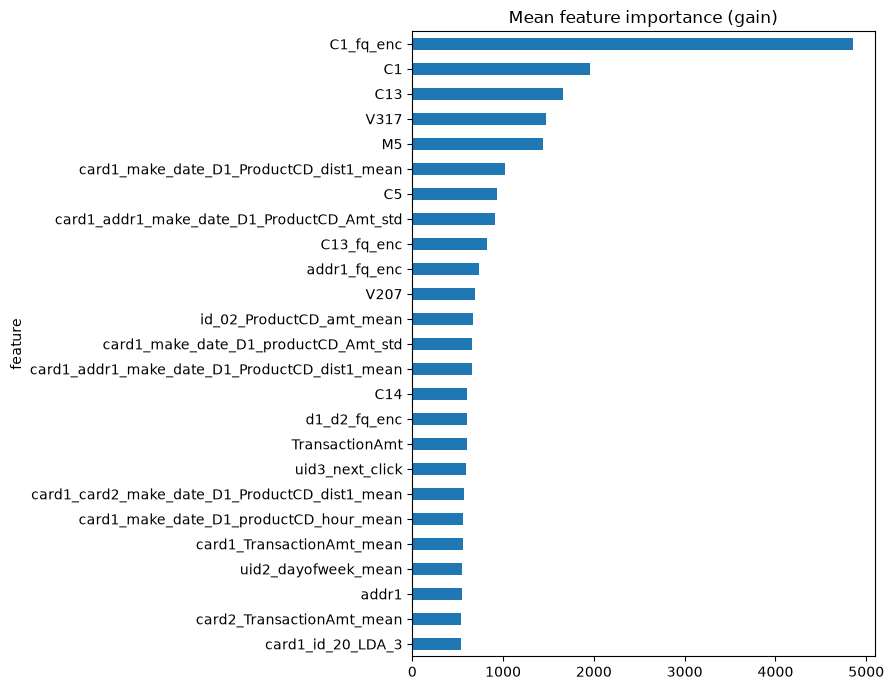

In [8]:
np.save(OUTPUT_DIR / "oof_train.npy", oof)
np.save(OUTPUT_DIR / "pred_test.npy", predictions)
pd.DataFrame({"TransactionID": train_ids, "isFraud": y, "prediction": oof}).to_csv(OUTPUT_DIR / "oof.csv", index=False)
test_predictions = pd.DataFrame({"TransactionID": test_ids, "isFraud": predictions})
prediction_file = "sample_predictions.csv"
if NROWS is None:
    sample = load_sample_submission()
    assert len(sample) == len(test_predictions) and sample.TransactionID.is_unique
    test_predictions = sample[["TransactionID"]].merge(test_predictions, on="TransactionID", how="left", validate="one_to_one")
    assert test_predictions.isFraud.notna().all()
    assert test_predictions.TransactionID.equals(sample.TransactionID)
    prediction_file = "submission.csv"
test_predictions.to_csv(OUTPUT_DIR / prediction_file, index=False)
importance = pd.concat(importances, ignore_index=True)
importance.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)

metrics = dict(source=source, tag=TAG, nrows=NROWS, train_rows=n_train, test_rows=len(test_ids),
               n_splits=N_SPLITS, seed=SEED, num_boost_round=NUM_BOOST_ROUND, params=params,
               preprocessing="Model2 train+test features; float32 after engineering; fold-local target mean",
               validation="ProductCD groups + shuffled StratifiedKFold",
               versions={name: version(name) for name in ["numpy", "pandas", "scikit-learn", "lightgbm"]},
               groups=group_results, folds=fold_results, feature_lists=feature_lists,
               oof_auc=score, elapsed_sec=round(time.time() - started, 1), prediction_file=prediction_file)
(OUTPUT_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2, ensure_ascii=False), encoding="utf-8")
log(f"Saved: {OUTPUT_DIR}; predictions={prediction_file}; elapsed={metrics['elapsed_sec']}s")
importance.groupby("feature").gain.mean().nlargest(25).sort_values().plot.barh(
    figsize=(9, 7), title="Mean feature importance (gain)")
plt.tight_layout()
plt.show()